# Demand Analysis
This notebook performs exploratory analysis for customer demand: loading data, basic cleaning, summary statistics, and demand visualizations.

In [9]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
%matplotlib inline

In [10]:
# Install dependencies listed in requirements.txt (run if needed)
%pip install -r ../requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Load data
Load the CSV files from the `data/` folder. Paths are relative to this notebook's location.

In [11]:
customers = pd.read_csv('../data/customers.csv')
warehouses = pd.read_csv('../data/warehouses.csv')
transport = pd.read_csv('../data/transport_cost.csv')

# Preview
customers.head()

,customer_id,x,y,demand
0,C1,10.5,23.4,120
1,C2,15.0,30.2,80
2,C3,8.2,19.1,150


## Basic cleaning
Apply simple cleaning: enforce numeric types, drop duplicates, and remove rows with missing critical fields.

In [12]:
# Ensure numeric columns in customers
for col in ['x','y','demand']:
    if col in customers.columns:
        customers[col] = pd.to_numeric(customers[col], errors='coerce')

customers = customers.drop_duplicates(subset='customer_id')
customers = customers.dropna(subset=['demand'])
customers['demand'] = customers['demand'].astype(int)

# Warehouses
for col in ['x','y','capacity']:
    if col in warehouses.columns:
        warehouses[col] = pd.to_numeric(warehouses[col], errors='coerce')
warehouses = warehouses.drop_duplicates(subset='warehouse_id')

# Transport costs
if 'cost_per_unit' in transport.columns:
    transport['cost_per_unit'] = pd.to_numeric(transport['cost_per_unit'], errors='coerce')
    transport = transport.dropna(subset=['cost_per_unit'])

# Quick info
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  3 non-null      str    
 1   x            3 non-null      float64
 2   y            3 non-null      float64
 3   demand       3 non-null      int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 228.0 bytes


## Summary statistics
Basic numerical summaries for customer demand.

In [13]:
demand_desc = customers['demand'].describe()
total_demand = customers['demand'].sum()
median_demand = customers['demand'].median()
print('Demand summary:\n', demand_desc)
print('\nTotal demand:', total_demand)
print('Median demand:', median_demand)

Demand summary:
 count      3.000000
mean     116.666667
std       35.118846
min       80.000000
25%      100.000000
50%      120.000000
75%      135.000000
max      150.000000
Name: demand, dtype: float64

Total demand: 350
Median demand: 120.0


## Demand visualization
Visualize spatial distribution and histograms of demand.

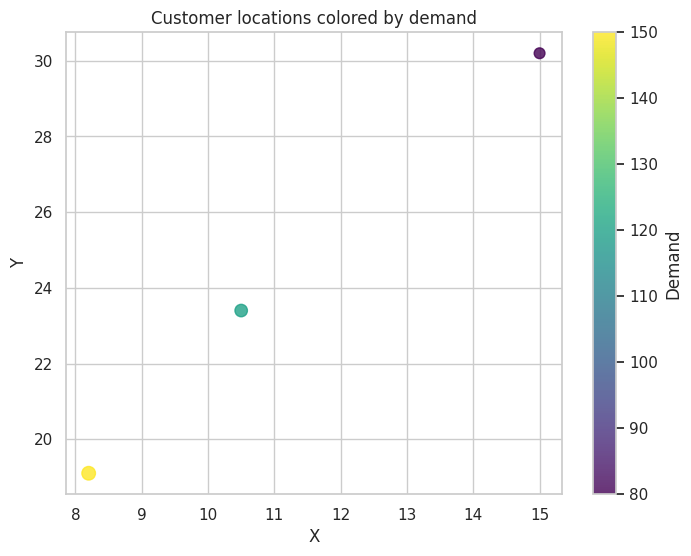

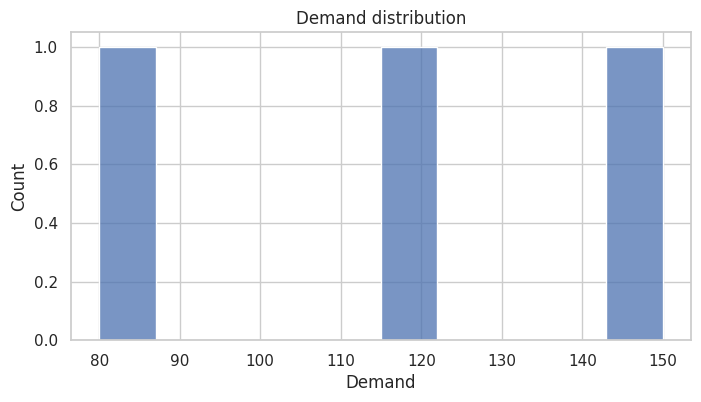

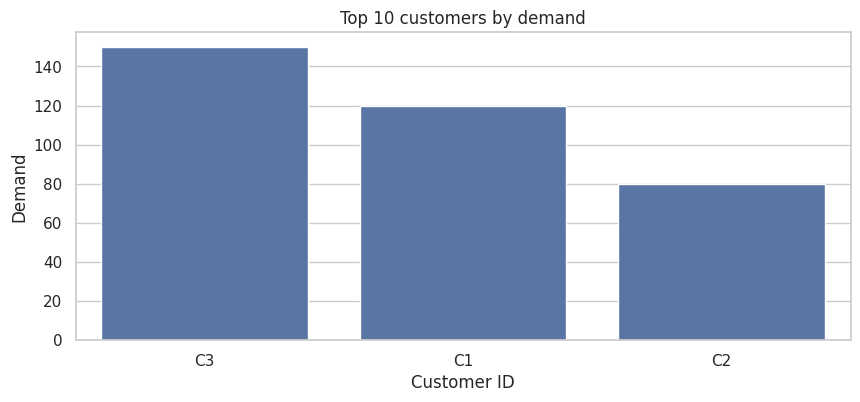

In [14]:
# Scatter: customer locations colored by demand
plt.figure(figsize=(8,6))
sc = plt.scatter(customers['x'], customers['y'], c=customers['demand'], s=customers['demand']/2 + 20, cmap='viridis', alpha=0.8)
plt.colorbar(sc, label='Demand')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Customer locations colored by demand')
plt.grid(True)
plt.show()

# Histogram of demand
plt.figure(figsize=(8,4))
sns.histplot(customers['demand'], bins=10, kde=False)
plt.title('Demand distribution')
plt.xlabel('Demand')
plt.show()

# Top customers by demand
top = customers.sort_values('demand', ascending=False).head(10)
plt.figure(figsize=(10,4))
sns.barplot(x='customer_id', y='demand', data=top)
plt.title('Top 10 customers by demand')
plt.xlabel('Customer ID')
plt.ylabel('Demand')
plt.show()

## Notes & next steps
- Validate coordinates and units.
- Aggregate demand by region or nearest warehouse.
- Use transport costs to build a cost-minimizing allocation model.